# Wykorzystanie metod sztucznej inteligencji w predykcji odpływu klientów

### Maksymilian Golonko, Piotr Kardyński, Jan Chrzanowski

Do realizacji projektu wybrany został zbiór danych Telco Customer Churn, który jest dostępny w serwisie Kaggle pod adresem: https://www.kaggle.com/datasets/blastchar/telco-customer-churn. Zbiór ten zawiera szczegółowe informacje o klientach firmy telekomunikacyjnej, uwzględniając ich profil demograficzny, typy posiadanych usług oraz parametry finansowe zawartych kontraktów.

Wybór tego zestawu danych jest uzasadniony przede wszystkim jego wysoką adekwatnością do postawionego problemu biznesowego. Predykcja odejścia klienta to zadanie analityczne, które w rzeczywistych warunkach rynkowych bezpośrednio przekłada się na strategię retencyjną firmy. Dane są kompletne i reprezentatywne, co pozwala na rzetelne odwzorowanie procesu decyzyjnego klientów.

Z punktu widzenia zastosowania metod sztucznej inteligencji, zbiór ten oferuje odpowiednią skalę i złożoność. Liczba ponad siedmiu tysięcy rekordów jest wystarczająca do poprawnego przeprowadzenia procesu uczenia, walidacji oraz testowania modeli bez ryzyka uzyskania wyników przypadkowych. Zbiór zawiera 21 różnorodnych parametrów opisujących klientów, co wymaga zastosowania metod wstępnego przetwarzania danych. Ze względu na to, że dane mają postać zarówno liczb, jak i opisów tekstowych, będziemy mogli pokazać proces przygotowania danych do formy, którą algorytmy AI potrafią poprawnie zinterpretować i przeliczyć.

Dodatkowo, zbiór posiada wyraźnie zdefiniowaną zmienną celu, co umożliwia zastosowanie szerokiego wachlarza algorytmów uczenia nadzorowanego. Naturalne niezbalansowanie klas w danych o churnie stanowi dodatkowy walor edukacyjny, wymuszając dobór zaawansowanych metryk oceny modelu.

### Analiza


C:\Users\janch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WCZYTANIE DANYCH
Liczba rekordów: 7043

TYPY DANYCH (POCZĄTKOWE):
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

ANALIZA JAKOŚCI


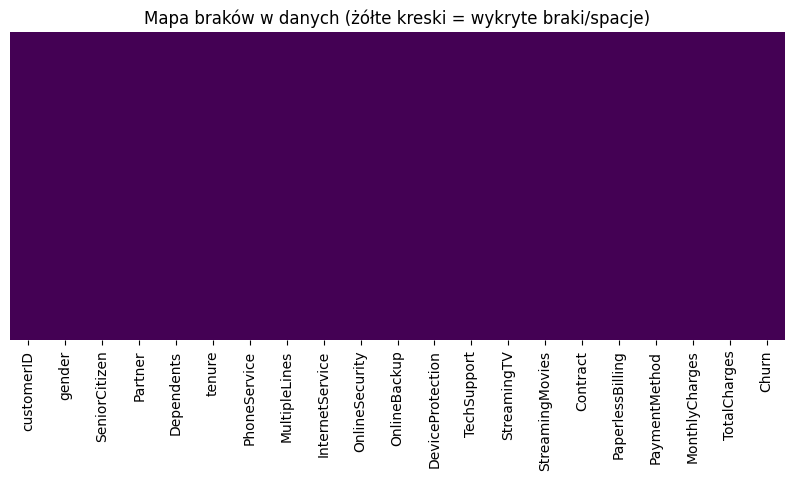


CZYSZCZENIE DANYCH
Liczba wykrytych braków (NaN) po konwersji: 11

FINALNE TYPY KLUCZOWYCH DANYCH:
TotalCharges    float64
Churn               str
dtype: object

ANALIZA JAKOŚCI


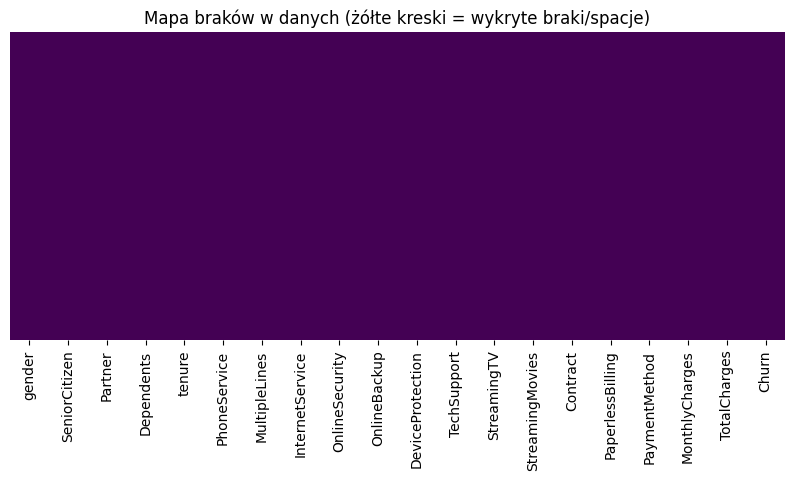

In [1]:
from baza import wczytanie, czyszczenie, wykresy_podstawowe, analiza_jakosci, mapa_korelacji_top12, analiza_jakosci
df = wczytanie()

analiza_jakosci(df)
df = czyszczenie(df)
analiza_jakosci(df)

(Każda żółta kreska ma wysokość dokładnie 1 wiersza. Ponieważ zbiór ma ponad 7 tysięcy wierszy, pojedyncza kreska jest cieńsza niż 1 piksel)

ANALIZA I STATYSTYKI

OPIS CECH NUMERYCZNYCH:
       SeniorCitizen   tenure  MonthlyCharges  TotalCharges    Churn
count        7043.00  7043.00         7043.00       7043.00  7043.00
mean            0.16    32.37           64.76       2279.73     0.27
std             0.37    24.56           30.09       2266.79     0.44
min             0.00     0.00           18.25          0.00     0.00
25%             0.00     9.00           35.50        398.55     0.00
50%             0.00    29.00           70.35       1394.55     0.00
75%             0.00    55.00           89.85       3786.60     1.00
max             1.00    72.00          118.75       8684.80     1.00


c:\Users\Piotrek\Desktop\projekt_programowanie\projekt\PMiNA\baza.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')
c:\Users\Piotrek\Desktop\projekt_programowanie\projekt\PMiNA\baza.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='magma')


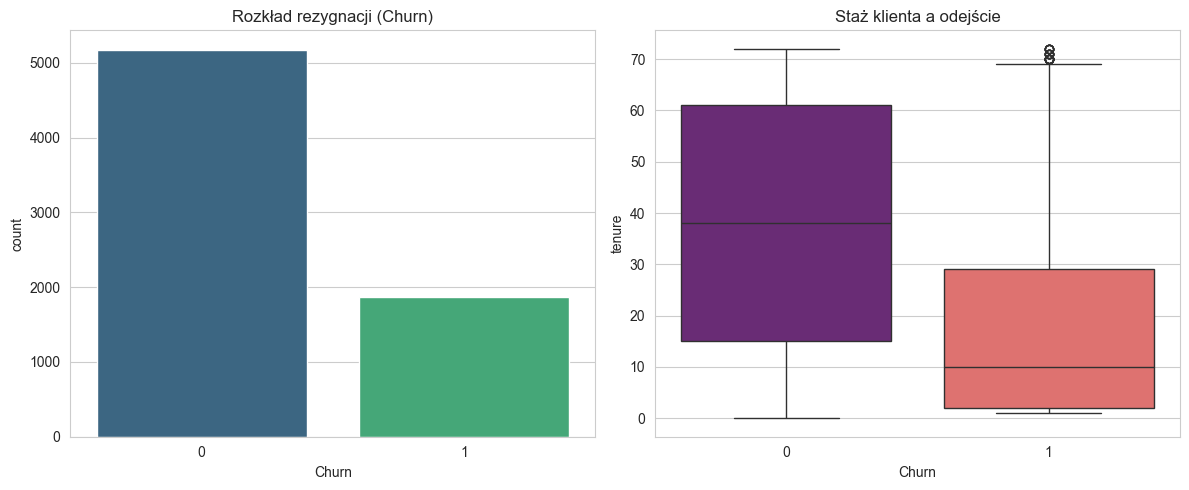

In [2]:
wykresy_podstawowe(df)

Z wykresów wynika, że większość klientów pozostaje w firmie, jednak istnieje wyraźna dysproporcja w stażu: osoby rezygnujące (Churn=1) to głównie nowi klienci z bardzo krótkim stażem. Sugeruje to, że krytyczny moment dla lojalności występuje na samym początku współpracy, a im dłużej klient korzysta z usług, tym rzadziej decyduje się na odejście.


Generowanie szczegółowej mapy korelacji (Top 12)...


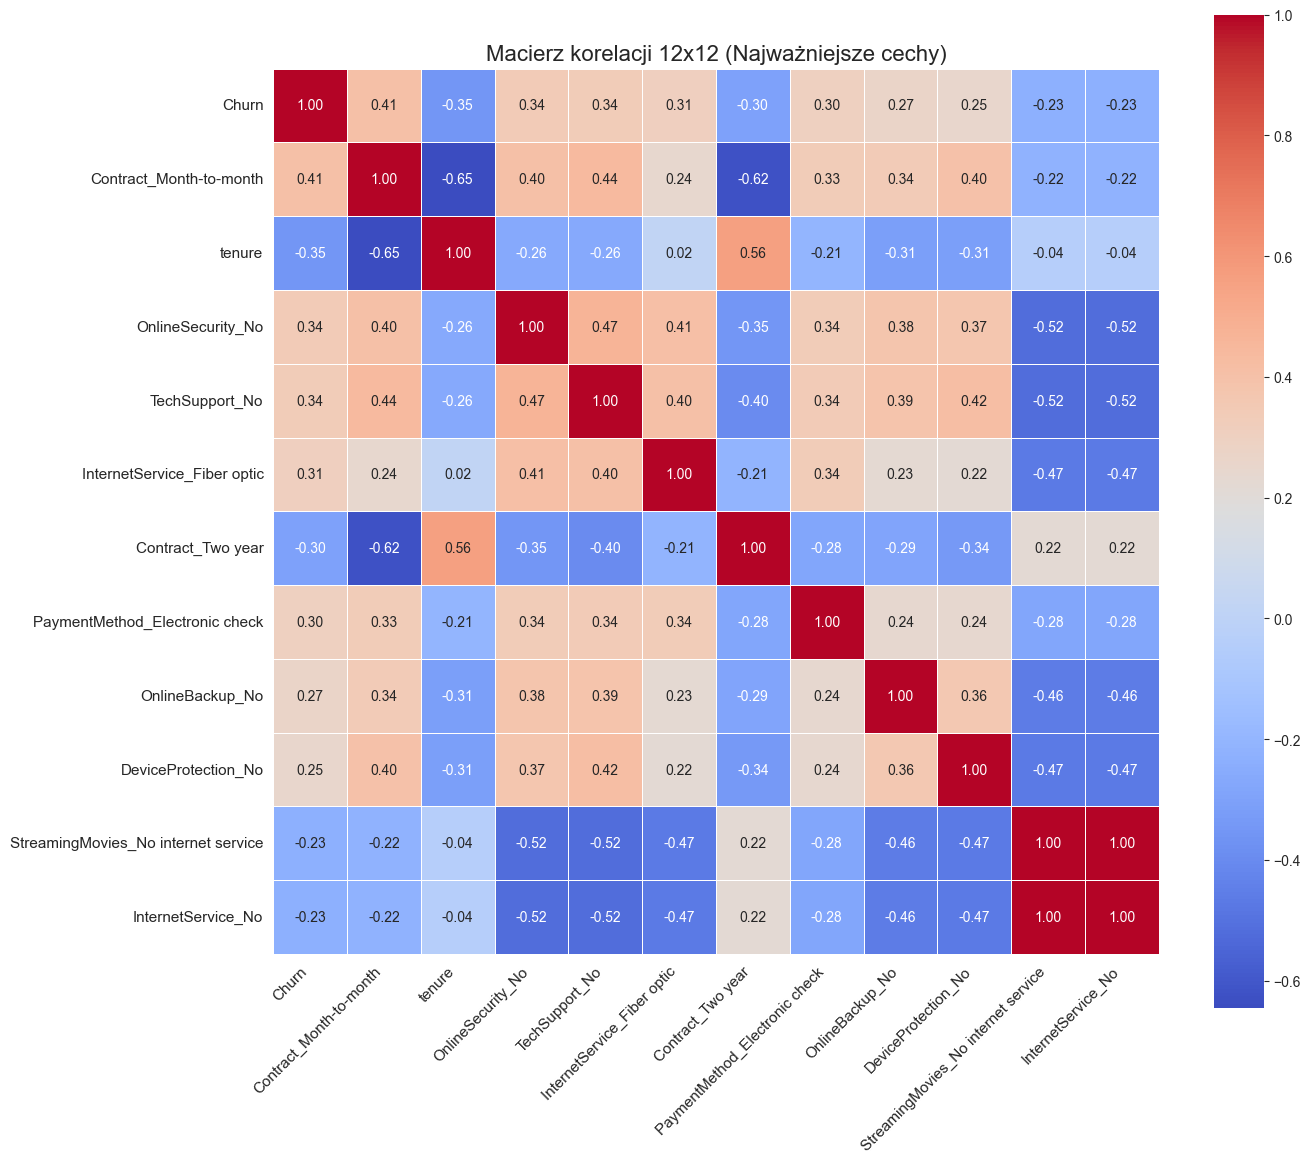

In [3]:
mapa_korelacji_top12(df)


* Najsilniejszym czynnikiem odejść są umowy "miesiąc do miesiąca" ($r = 0,41$), co pokazuje, że klienci bez długofalowych zobowiązań rezygnują najszybciej.
* Brak pakietów bezpieczeństwa i wsparcia technicznego wyraźnie sprzyja rezygnacjom, co sugeruje, że oferowanie kompleksowej obsługi realnie zwiększa przywiązanie klienta do firmy.
*  Użytkownicy najnowocześniejszej technologii (Fiber optic) odchodzą częściej niż inni ($r = 0,31$), co wskazuje na problem z utrzymaniem wymagających klientów, mimo oferowania im teoretycznie najlepszej usługi.

### Sformułowanie hipotezy badawczej

**Problem biznesowy i analityczny:**
Zadanie polega na klasyfikacji binarnej. Model ma za zadanie przewidzieć, czy dany klient zrezygnuje z usług firmy (zmienna `Churn` przyjmie wartość "Yes"), czy też pozostanie lojalny ("No"), na podstawie jego profilu demograficznego, finansowego oraz posiadanych usług.

**Hipoteza główna:**
Zastosowanie algorytmów uczenia maszynowego (takich jak Regresja Logistyczna, Lasy Losowe czy XGBoost) pozwoli na zbudowanie modelu klasyfikacyjnego, który z wysoką czułością (Recall) oraz precyzją zidentyfikuje klientów zagrożonych odejściem. Umożliwi to firmie podjęcie celowanych działań retencyjnych przed faktycznym zerwaniem umowy.

**Hipotezy szczegółowe (wynikające z przeprowadzonej analizy EDA):**
1. **Typ kontraktu a lojalność:** Klienci posiadający umowę krótkoterminową typu "Month-to-month" wykazują najwyższą skłonność do migracji. Zmienna ta będzie miała jeden z najwyższych współczynników istotności w procesie trenowania modelu.
2. **Infrastruktura a jakość usług:** Użytkownicy internetu światłowodowego (Fiber optic) odchodzą częściej niż użytkownicy innych technologii, co sugeruje ukryty problem z retencją w tym segmencie (np. wysoka cena lub kwestie techniczne). Model powinien mocno reagować na tę cechę.
3. **Wpływ usług wsparcia:** Brak dodatkowych pakietów niefinansowych, takich jak wsparcie techniczne (*TechSupport*) czy bezpieczeństwo online (*OnlineSecurity*), istotnie zwiększa prawdopodobieństwo odejścia klienta.

**Definicja miar sukcesu modelu:**
Ponieważ celem biznesowym jest zatrzymanie jak największej liczby klientów, kluczową metryką efektywności modelu nie będzie ogólna dokładność (*Accuracy*), lecz:
* **Czułość (Recall / Sensitivity):** Chcemy zminimalizować błędy drugiego rodzaju (sytuacje, w których model uzna, że klient zostanie, a on odejdzie).
* **F1-Score:** Jako średnia harmoniczna precyzji i czułości, pozwoli ocenić stabilność modelu przy potencjalnym niezbalansowaniu klas w zbiorze danych.

### Badanie aktualnego stanu wiedzy

Predykcja odpływu klientów w sektorze telekomunikacyjnym to jeden z klasycznych i najlepiej przebadanych problemów na styku uczenia maszynowego i biznesu. Analiza literatury oraz istniejących wdrożeń pozwala wyróżnić trzy główne grupy podejść do tego zagadnienia:

#### 1. Tradycyjne modele statystyczne
Wczesne systemy predykcji opierały się głównie na **Regresji Logistycznej (Logistic Regression)**. 
* **Zalety:** Ogromną zaletą tego podejścia jest pełna interpretowalność – współczynniki modelu wprost wskazują, jak silnie dana cecha (np. rodzaj umowy czy brak wsparcia technicznego) wpływa na prawdopodobieństwo odejścia.
* **Ograniczenia:** Regresja logistyczna zakłada liniowe zależności między zmiennymi, przez co rzadko osiąga najwyższą dokładność w przypadku złożonych, nieliniowych zachowań klientów. Obecnie stosuje się ją głównie jako model bazowy (*baseline*).

#### 2. Klasyczne algorytmy uczenia maszynowego (Standard branżowy)
Współczesne podejścia w biznesie zdominowane są przez algorytmy oparte na drzewach decyzyjnych. Dla danych tabelarycznych (takich jak zbiór Telco) osiągają one najlepsze rezultaty:
* **Lasy Losowe (Random Forest):** Tworzą zespół wielu drzew decyzyjnych, co skutecznie zapobiega przeuczeniu i pozwala na automatyczną ocenę istotności cech (*feature importance*).
* **Algorytmy Gradient Boosting (XGBoost, LightGBM, CatBoost):** Sekwencyjne budowanie drzew, gdzie każde kolejne poprawia błędy poprzednika. W konkursach platformy Kaggle oraz w systemach produkcyjnych korporacji, **XGBoost** jest obecnie uznawany za najskuteczniejsze narzędzie do predykcji churnu ze względu na radzenie sobie z nieliniowościami i brakami w danych.

#### 3. Głębokie uczenie (Deep Learning)
W przypadku bardzo dużych zbiorów danych (wielomilionowe bazy operatorów) stosuje się wielowarstwowe sieci neuronowe (np. **MLP – Multi-Layer Perceptron**). Choć potrafią one wykryć bardzo abstrakcyjne wzorce zachowań, w praktyce biznesowej często ustępują modelom drzewiastym ze względu na tzw. efekt „czarnej skrzynki” (trudność w wyjaśnieniu, *dlaczego* sieć podjęła daną decyzję) oraz wysokie wymagania sprzętowe.

#### Kluczowe wyzwania identyfikowane w literaturze:
* **Niezbalansowanie klas:** W rzeczywistych bazach danych telekomunikacyjnych liczba klientów odchodzących stanowi zazwyczaj mniejszość (w zbiorze Telco jest to ok. 26%). Stan wiedzy wskazuje na konieczność stosowania technik balansowania danych, takich jak **SMOTE** (syntetyczne generowanie próbek klasy mniejszościowej) lub modyfikacja wag klas bezpośrednio w algorytmie (*class_weight*).
* **Koncentracja na metrykach biznesowych:** Publikacje naukowe zgodnie podkreślają, że miara *Accuracy* (ogólna dokładność) bywa myląca przy niezbalansowanych klasach. Standardem jest optymalizacja modeli pod kątem krzywej **ROC-AUC** oraz maksymalizacja miary **Recall (czułości)**, aby wykryć jak największą liczbę klientów realnie zagrożonych odejściem.

## Analiza potencjalnych kandydatów na model

Nasz problem biznesowy to klasyfikacja binarna – przewidujemy, czy dany klient odejdzie z sieci (`Churn = Yes`), czy zostanie (`Churn = No`). Pracujemy na zbiorze Telco Customer Churn, który ma kilka ważnych cech: klasy są niezbalansowane (odchodzący to tylko ok. 26% całości), mamy mix danych liczbowych i tekstowych oraz silną korelację między opłatami miesięcznymi a całkowitymi.

Żeby sprawdzić, który algorytm poradzi sobie najlepiej, wybraliśmy do analizy 4 różne modele:

---

### 1. Regresja Logistyczna (Logistic Regression)

* **Sposób działania:** To prosty model liniowy. Mnoży każdą cechę klienta przez odpowiednią wagę, sumuje to wszystko, a wynik przepuszcza przez funkcję sigmoidalną. Dzięki temu dostajemy czysty wynik z przedziału od 0 do 1, który interpretujemy jako prawdopodobieństwo odejścia klienta.
* **Zalety:** Działa błyskawicznie i jest bardzo łatwa do wyjaśnienia biznesowi – z wag modelu od razu widać, które cechy najsilniej pchają klienta do odejścia. Ma wbudowany parametr `class_weight='balanced'`, co bardzo pomaga przy naszych nierównych klasach.
* **Wady:** Zakłada, że relacje w danych są proste i liniowe. Nie wyłapie sama skomplikowanych zależności między cechami. Jest też bardzo wrażliwa na współliniowość (czyli dublowanie informacji, jak u nas przy opłatach).
* **Dopasowanie do problemu:** Wrzucamy ją jako nasz model bazowy (baseline). Zobaczymy, czy najprostsze podejście wystarczy, żeby sensownie wyłapywać odchodzących klientów.

---

### 2. Las Losowy (Random Forest Classifier)

* **Sposób działania:** Model zespołowy. Tworzy jednocześnie mnóstwo osobnych drzew decyzyjnych. Każde drzewo dostaje trochę inny, losowy wycinek danych i cech. Na koniec model zbiera głosy ze wszystkich drzew i wybiera tę decyzję, którą wskazała większość.
* **Zalety:** Rzadko się przeucza (jest odporny na overfitting), nie wymaga wcześniejszego skalowania liczb (np. zamiany na wartości od 0 do 1) i potrafi sam pokazać, które cechy były najważniejsze przy podejmowaniu decyzji.
* **Wady:** Działa trochę jak "szara skrzynka" – ciężko przeanalizować logicznie decyzję, za którą stoi kilkaset różnych drzew. Może też zajmować sporo pamięci przy dużych lasach.
* **Dopasowanie do problemu:** Idealnie pasuje do naszych danych, bo mamy tu dużo zmiennych tekstowych (np. rodzaj umowy czy sposób płatności), z którymi drzewa radzą sobie naturalnie. Problem proporcji klas rozwiążemy parametrem `class_weight='balanced_subsample'`.

---

### 3. XGBoost (Extreme Gradient Boosting)

* **Sposób działania:** Też model oparty na drzewach decyzyjnych, ale buduje je po kolei (sekwencyjnie), a nie na raz. Każde kolejne drzewo skupia się wyłącznie na poprawianiu błędów, które zrobiły drzewa stworzone przed nim.
* **Zalety:** Obecnie jeden z najpotężniejszych algorytmów dla danych tabelarycznych. Ma świetne zabezpieczenia przed przeuczeniem i wbudowany parametr `scale_pos_weight`, stworzony specjalnie do walki z niezbalansowanymi klasami.
* **Wady:** Ma mnóstwo suwaków i parametrów do ustawienia (hiperparametrów). Jeśli źle je dobierzemy, model łatwo zepsuć. Podobnie jak Las Losowy – jest trudny do bezpośredniej interpretacji.
* **Dopasowanie do problemu:** Chcemy wyciągnąć jak najwyższą miarę Recall (czyli wyłapać jak najwięcej realnie zagrożonych klientów). XGBoost daje nam nad tym największą kontrolę matematyczną i powinien dać najlepsze wyniki.

---

### 4. Prosta Sieć Neuronowa (MLP - Multi-Layer Perceptron)

* **Sposób działania:** Model sztucznej sieci neuronowej. Dane wejściowe przechodzą przez warstwy ukryte składające się z neuronów, gdzie są mieszane i przetwarzane nieliniowo. Sieć uczy się na swoich błędach, kręcąc wagami tak, żeby w ostatecznym neuronie wyjściowym wyszła poprawna decyzja.
* **Zalety:** Teoretycznie potrafi wykryć nawet najbardziej ukryte i skomplikowane wzorce w danych, których zwykłe algorytmy nigdy by nie zauważyły.
* **Wady:** To całkowita "czarna skrzynka". Bardzo łatwo się przeucza (overfitting), kiedy danych jest stosunkowo mało (nasz zbiór ma ok. 7 tysięcy wierszy). Wymaga też przygotowania danych: wszystko trzeba ręcznie poskalować i zakodować na liczby, bo inaczej sieć w ogóle nie ruszy.
* **Dopasowanie do problemu (Świadomy wybór do celów eksperymentalnych):** Choć literatura wskazuje, że sieci neuronowe na średnich danych tabelarycznych radzą sobie słabiej niż drzewa, **decydujemy się na jej implementację**. Chcemy przetestować ten model i zestawić go z algorytmami drzewiastymi. Pozwoli nam to dowieść w praktyce założeń teoretycznych i pokazać na wykresach wyraźny kontrast między modelami optymalnymi a niedopasowanymi do tej skali problemu.

---

### Podsumowanie modeli

| Cecha / Kryterium | Regresja Logistyczna | Las Losowy | XGBoost | Sieć Neuronowa (MLP) |
| :--- | :--- | :--- | :--- | :--- |
| **Rodzaj modelu** | Liniowy | Zespół drzew (Bagging) | Zespół drzew (Boosting) | Sieć Neuronowa |
| **Łatwość wyjaśnienia wyników** | Bardzo wysoka | Średnia (Szara skrzynka) | Niska | Bardzo niska (Czarna skrzynka) |
| **Czy wymaga skalowania liczb?**| Tak | Nie | Nie | Tak (bardzo) |
| **Odporność na przeuczenie**| Wysoka | Wysoka | Średnia (wymaga uwagi) | Niska |
| **Obsługa braku balansu klas** | Dobra (`class_weight`) | Bardzo dobra | Doskonała (`scale_pos_weight`) | Trudna |

### Ostateczny wybór modeli do implementacji

Po przeanalizowaniu teorii zdecydowaliśmy się na wdrożenie **trzech modeli**, co pozwoli na bardzo szerokie i rzetelne porównanie wyników w części implementacyjnej:

1. **XGBoost** – nasz główny faworyt. Najmocniejszy algorytm do danych tabelarycznych, z doskonałą, wbudowaną obsługą niezbalansowanych klas (`scale_pos_weight`).
2. **Las Losowy (Random Forest)** – drugi mocny kandydat oparty na drzewach. Stabilny, odporny na przeuczenie, działający na zasadzie równoległego głosowania (Bagging), co stworzy świetne porównanie dla sekwencyjnego XGBoosta (Boosting).
3. **Sieć Neuronowa (MLP)** – model eksperymentalny. Wybrany świadomie jako algorytm, który według teorii powinien poradzić sobie najsłabiej z tej trójki. Posłuży nam jako punkt odniesienia do pokazania, jak modele głębokiego uczenia potrafią przegrać z algorytmami drzewiastymi na danych tabelarycznych o rozmiarze ok. 7 tysięcy wierszy.

Jedynym modelem odrzuconym na etapie analizy teoretycznej jest Regresja Logistyczna, jako zbyt prosta do wychwycenia nieliniowych relacji finansowych w naszym zbiorze.